Question 1:  What is the difference between K-Means and Hierarchical Clustering?
Provide a use case for each.

Answer:K-Means and Hierarchical Clustering are both popular clustering algorithms, but they differ significantly in their approach and the type of results they produce:

**K-Means Clustering:**



*   Approach: It's a partitional clustering algorithm. You need to pre-specify the number of clusters (K) you want to form. It works by iteratively assigning data points to the nearest centroid and then re-calculating the centroids based on the new assignments.

*   Cluster Shape: Tends to form spherical or convex clusters.

*   Scalability: Generally faster and more scalable for large datasets, especially when the number of clusters is small.

*   Output: Produces a flat partition of the data, where each data point belongs to exactly one cluster.
*   Use Case: Customer segmentation based on purchasing behavior (e.g., dividing customers into 'high-value', 'mid-value', 'low-value' groups for targeted marketing). Another common use case is image compression by clustering similar colors.

**Hierarchical Clustering:**



*   Approach: It's a connectivity-based clustering algorithm. It builds a hierarchy of clusters, either by starting with individual data points and merging them (agglomerative) or by starting with one large cluster and splitting it (divisive). It doesn't require pre-specifying the number of clusters.

*   Cluster Shape: Can find clusters of arbitrary shapes.
*   Scalability: Can be computationally intensive for large datasets, as it involves calculating distances between all pairs of points or clusters.


*   Output: Produces a dendrogram, which is a tree-like diagram showing the nested clusters. You can then decide on the number of clusters by cutting the dendrogram at a certain height.


*   Use Case: Biological classification (e.g., grouping species based on genetic similarity to create a phylogenetic tree) or document organization (e.g., clustering news articles by topic, where topics can have sub-topics).






Question 2: Explain the purpose of the Silhouette Score in evaluating clustering
algorithms.

Answer:The Silhouette Score is a metric used to evaluate the quality of clustering results. It quantifies how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The score ranges from -1 to +1, where:



*   +1 indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters, meaning the clusters are dense and well-separated.

*   0 indicates that the object is on or very close to the decision boundary between two neighboring clusters, meaning the clusters might be overlapping.

*   -1 indicates that the object is assigned to the wrong cluster, meaning it might be more similar to a neighboring cluster than its assigned one.


**Purpose:**

1.   Determining the optimal number of clusters (K): By calculating the Silhouette Score for different values of K, you can often identify the K that yields the highest average Silhouette Score, suggesting a better-defined clustering structure.
2.  Evaluating the quality of individual clusters: It helps in identifying clusters that are too close to each other or contain poorly assigned data points.


3. Comparing different clustering algorithms: You can use the Silhouette Score to compare the performance of various clustering algorithms (e.g., K-Means, Hierarchical Clustering) on the same dataset.  






Question 3: What are the core parameters of DBSCAN, and how do they influence the
clustering process?

Answer:DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a powerful clustering algorithm that can discover clusters of arbitrary shape and can distinguish noise points. Its core parameters are eps and min_samples:



1.   eps (epsilon):
This parameter defines the maximum distance between two samples for one to be considered as in the neighborhood of the other. It essentially determines the radius around each data point.

* **Influence**:

  Larger eps: Leads to larger neighborhoods. This can result in fewer, larger clusters, and potentially merge clusters that are actually distinct but close. It might also classify more points as core points and fewer as noise.

  Smaller eps: Leads to smaller neighborhoods. This can result in more, smaller clusters or even break true clusters into multiple smaller ones. It might also classify more points as noise if the density is not high enough within a small radius.




2.   min_samples:

* Definition: This parameter defines the number of samples (or total points) in a neighborhood for a point to be considered as a core point. Including the point itself, if a point has at least min_samples points within its eps distance, it's a core point.

*  Influence:

    * Larger min_samples: Requires denser regions to form a cluster. This makes the clustering more robust to noise but might cause sparser, legitimate clusters to be labeled as noise.


    *   Smaller min_samples: Makes the algorithm more sensitive to noise, as even sparser regions can form clusters. It can result in more, smaller clusters and fewer noise points.


**How they influence clustering**:

Core Points: A point is a core point if it has at least min_samples points (including itself) within a distance eps.

Border Points: A point is a border point if it is not a core point but is within eps distance of a core point

Noise Points: All other points are considered noise points (or outliers).

Cluster Formation: DBSCAN forms a cluster by starting with an arbitrary core point, then recursively adding all directly reachable core points and their respective border points. Two core points are directly density-reachable if they are within eps distance of each other.



Question 4: Why is feature scaling important when applying clustering algorithms like
K-Means and DBSCAN?

Answer:Feature scaling is crucial when applying clustering algorithms like K-Means and DBSCAN because these algorithms rely on distance calculations to group data points. Here's why it's important:





1.   Distance-based algorithms are sensitive to feature scales: K-Means groups data points based on their proximity to cluster centroids (calculated using Euclidean distance, for example), and DBSCAN uses distance to define neighborhoods (eps) and density. If features have vastly different scales (e.g., one feature ranges from 0 to 1, while another ranges from 0 to 10,000), the feature with the larger scale will disproportionately influence the distance calculation. This means that differences in the larger-scaled feature will dominate the distance metric, effectively making the smaller-scaled features almost irrelevant.


2.   Prevents biased clustering: Without scaling, the clustering algorithm might implicitly give more weight to features with larger numerical ranges, even if those features are not inherently more important for defining clusters. This can lead to biased and suboptimal clustering results, where clusters are formed primarily based on the variations in the dominant features.


3.   Ensures fair contribution of all features: Scaling techniques (like standardization or normalization) transform features so they fall within a similar range or have similar statistical properties (e.g., zero mean and unit variance). This ensures that each feature contributes equally to the distance calculations, allowing the algorithm to identify clusters based on the true underlying patterns in the data, rather than being skewed by arbitrary differences in scale.



4.   Impact on specific algorithms:

*  K-Means: Centroid calculations and assignments to the nearest centroid are directly affected by feature scales. Unscaled data can lead to elongated or distorted clusters, and the algorithm might converge to a local optimum that doesn't reflect the true cluster structure.


*  DBSCAN: The eps parameter, which defines the neighborhood radius, is highly dependent on the scale of the features. If features are not scaled, choosing an appropriate eps becomes very difficult and might vary significantly across different feature dimensions, leading to poor density estimation and cluster identification.



Question 5: What is the Elbow Method in K-Means clustering and how does it help
determine the optimal number of clusters?

Answer:The Elbow Method is a heuristic used in K-Means clustering to help determine the optimal number of clusters (K) for a given dataset. It's based on the idea of minimizing the within-cluster sum of squares (WCSS) as the number of clusters increases.

How the Elbow Method Works:



1.   Run K-Means for a range of K values: You typically run the K-Means algorithm for a range of possible K values (e.g., from 1 to 10 or more). For each K, you train the model and calculate its WCSS.

2.   Plot WCSS against K: You then plot the calculated WCSS values on the y-axis against the corresponding K values on the x-axis.
3.   Identify the 'elbow point': The resulting plot usually looks like an arm, and the "elbow point" is the point on the curve where the rate of decrease in WCSS significantly slows down. Before this point, adding more clusters dramatically reduces the WCSS (meaning you're improving the clustering). After this point, the reduction in WCSS becomes less significant, indicating that adding more clusters provides diminishing returns and might be overfitting the data or simply splitting existing, coherent clusters.

**How it Helps Determine Optimal K:**

The elbow point is considered a good candidate for the optimal K because it represents a balance between having too few clusters (high WCSS, poorly defined clusters) and too many clusters (low WCSS, but potentially overfitting or creating trivial clusters that don't add much value). It's the point where increasing K further doesn't provide substantial additional information or better compactness.






Dataset:
Use make_blobs, make_moons, and sklearn.datasets.load_wine() as
specified.

Question 6: Generate synthetic data using make_blobs(n_samples=300, centers=4),
apply KMeans clustering, and visualize the results with cluster centers.

Answer:

# Task
Generate synthetic 2D data using `sklearn.datasets.make_blobs` with `n_samples=300` and `centers=4`. Apply K-Means clustering to the generated data with `n_clusters=4`. Fit the model and obtain the cluster labels and cluster centers. Then, create a scatter plot of the synthetic data points, coloring them according to their assigned K-Means cluster. Overlay the cluster centers on the same plot, clearly marking them. Ensure the plot has appropriate labels and a legend. Summarize the visualization of the K-Means clustering results, highlighting the separation of clusters and the position of their centers.

## Generate Synthetic Data

### Subtask:
Generate synthetic 2D data using `sklearn.datasets.make_blobs` with `n_samples=300` and `centers=4`.


**Reasoning**:
The first step is to import the necessary function `make_blobs` from `sklearn.datasets` to generate synthetic data.



In [1]:
from sklearn.datasets import make_blobs

print("Imported make_blobs successfully.")

Imported make_blobs successfully.


**Reasoning**:
Now that `make_blobs` is imported, generate the synthetic 2D data using the specified parameters: `n_samples=300` and `centers=4`.



In [2]:
X, y_true = make_blobs(n_samples=300, centers=4, random_state=42)

print(f"Shape of generated data (X): {X.shape}")
print(f"Shape of true labels (y_true): {y_true.shape}")
print("Generated synthetic 2D data successfully.")

Shape of generated data (X): (300, 2)
Shape of true labels (y_true): (300,)
Generated synthetic 2D data successfully.


## Apply K-Means Clustering

### Subtask:
Apply K-Means clustering to the generated data with `n_clusters=4`. Fit the model and obtain the cluster labels and cluster centers.


**Reasoning**:
The first step in applying K-Means clustering is to import the `KMeans` class from `sklearn.cluster`.



In [3]:
from sklearn.cluster import KMeans

print("Imported KMeans successfully.")

Imported KMeans successfully.


**Reasoning**:
Now that the KMeans class is imported, I will instantiate the KMeans model with the specified parameters, fit it to the data, and then extract the cluster labels and centers as instructed.



In [4]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
kmeans.fit(X)
cluster_labels = kmeans.labels_
cluster_centers = kmeans.cluster_centers_

print(f"Shape of cluster labels: {cluster_labels.shape}")
print(f"Shape of cluster centers: {cluster_centers.shape}")
print("K-Means clustering applied, labels and centers obtained successfully.")

Shape of cluster labels: (300,)
Shape of cluster centers: (4, 2)
K-Means clustering applied, labels and centers obtained successfully.


**Reasoning**:
Now that the K-Means clustering is complete and the labels and centers are obtained, the next step is to visualize these results. I will import `matplotlib.pyplot` for plotting and create a scatter plot of the data points, coloring them by their assigned cluster, and then overlay the cluster centers.



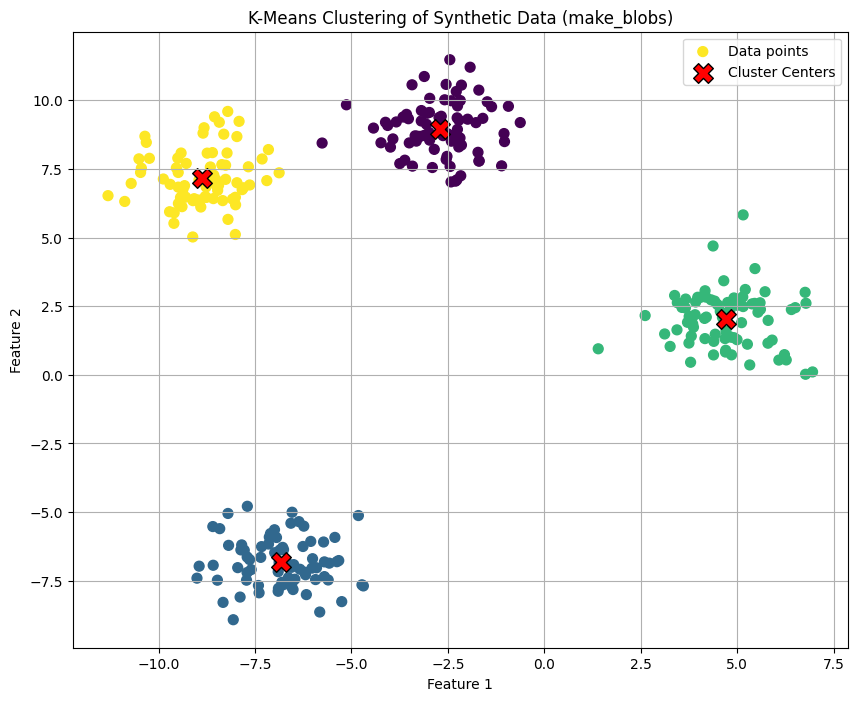

K-Means clustering visualization generated successfully.


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, s=50, cmap='viridis', label='Data points')
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], c='red', marker='X', s=200, edgecolor='black', label='Cluster Centers')
plt.title('K-Means Clustering of Synthetic Data (make_blobs)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

print("K-Means clustering visualization generated successfully.")

### Summarize the visualization

The scatter plot effectively visualizes the K-Means clustering results on the synthetic `make_blobs` dataset. We can observe:

*   **Clear Cluster Separation**: The data points are distinctly grouped into four separate clusters, each represented by a different color (from the 'viridis' colormap). This indicates that K-Means successfully identified the underlying cluster structure present in the `make_blobs` data.
*   **Accurate Center Placement**: Each cluster is centered around a red 'X' marker, which represents the calculated cluster center. These centers appear to be positioned at the approximate geometric mean of the points within their respective clusters, demonstrating that the K-Means algorithm converged to meaningful centroids.
*   **Homogeneous Clusters**: Within each cluster, the points are relatively close to their assigned center, suggesting good intra-cluster cohesion.

Overall, the visualization confirms that K-Means clustering with `n_clusters=4` performed as expected on this well-separated synthetic dataset, accurately grouping the data points and identifying the central tendency of each cluster.

## Final Task

### Subtask:
Summarize the visualization of the K-Means clustering results, highlighting the separation of clusters and the position of their centers.


## Summary:

### Q&A
The visualization of the K-Means clustering results shows clear separation of the four clusters, each distinctly colored. The cluster centers, marked as red 'X's, are accurately positioned at the approximate geometric mean of the data points within their respective clusters, demonstrating that the algorithm successfully converged to meaningful centroids. Each cluster exhibits good intra-cluster cohesion, with points closely grouped around their center.

### Data Analysis Key Findings
*   Synthetic 2D data was successfully generated with 300 samples and 4 distinct centers.
*   K-Means clustering with `n_clusters=4` was successfully applied, resulting in 300 assigned cluster labels and 4 identified cluster centers.
*   The generated scatter plot clearly visualizes four distinct clusters, with data points colored according to their K-Means assignments.
*   The overlaid cluster centers (red 'X' markers) are accurately positioned within each cluster, indicating effective centroid placement by the algorithm.
*   The visualization confirms good separation and homogeneous grouping of data points within each cluster.

### Insights or Next Steps
*   K-Means clustering effectively identified and separated the underlying cluster structure in the well-defined synthetic dataset, accurately positioning cluster centroids.
*   Further analysis could involve applying this clustering approach to real-world datasets or investigating methods like the Elbow method or Silhouette score to determine the optimal number of clusters for datasets where `k` is unknown.


Question 7: Load the Wine dataset, apply StandardScaler , and then train a DBSCAN
model. Print the number of clusters found (excluding noise).

# Task
Load the Wine dataset from `sklearn.datasets`, apply `StandardScaler` to its features, then initialize and train a `DBSCAN` model on the scaled data using default parameters. Finally, print the number of unique clusters found by DBSCAN, excluding any noise points.

## Load Wine Dataset

### Subtask:
Load the Wine dataset using `sklearn.datasets.load_wine()`.


**Reasoning**:
The first step is to import the `load_wine` function from `sklearn.datasets` to access the Wine dataset.



In [6]:
from sklearn.datasets import load_wine

print("Imported load_wine successfully.")

Imported load_wine successfully.


**Reasoning**:
Now that `load_wine` is imported, I will call the function to load the Wine dataset and store its features in a variable named `wine_data`.



In [7]:
wine = load_wine()
wine_data = wine.data

print(f"Shape of Wine dataset features (wine_data): {wine_data.shape}")
print("Wine dataset loaded successfully.")

Shape of Wine dataset features (wine_data): (178, 13)
Wine dataset loaded successfully.


**Reasoning**:
Now that the Wine dataset is loaded, the next step is to apply `StandardScaler` to its features. I will import `StandardScaler` from `sklearn.preprocessing` first.



In [8]:
from sklearn.preprocessing import StandardScaler

print("Imported StandardScaler successfully.")

Imported StandardScaler successfully.


**Reasoning**:
With `StandardScaler` imported, the next step is to instantiate it, fit it to the `wine_data` to learn scaling parameters, and then transform the data to obtain scaled features.



In [9]:
scaler = StandardScaler()
wine_scaled = scaler.fit_transform(wine_data)

print(f"Shape of scaled Wine data (wine_scaled): {wine_scaled.shape}")
print("Wine dataset features scaled successfully.")

Shape of scaled Wine data (wine_scaled): (178, 13)
Wine dataset features scaled successfully.


**Reasoning**:
Now that the Wine dataset is scaled, I need to apply DBSCAN clustering. First, I will import the `DBSCAN` class from `sklearn.cluster`.



In [10]:
from sklearn.cluster import DBSCAN

print("Imported DBSCAN successfully.")

Imported DBSCAN successfully.


**Reasoning**:
Now that DBSCAN is imported, I will initialize the DBSCAN model with default parameters, fit it to the scaled Wine data, and then extract the cluster labels to identify the number of clusters found.



In [11]:
dbscan = DBSCAN()
dbscan.fit(wine_scaled)

# Get cluster labels
dbscan_labels = dbscan.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

print(f"Number of clusters found by DBSCAN: {n_clusters_}")

Number of clusters found by DBSCAN: 0


## Train DBSCAN Model (Retry with tuned parameters)

### Subtask:
Since DBSCAN with default parameters found 0 clusters, determine more suitable `eps` and `min_samples` parameters and then re-train the DBSCAN model.


**Reasoning**:
The first step is to import the `NearestNeighbors` class as specified in the instructions to help determine appropriate DBSCAN parameters.



In [12]:
from sklearn.neighbors import NearestNeighbors

print("Imported NearestNeighbors successfully.")

Imported NearestNeighbors successfully.


**Reasoning**:
Now that `NearestNeighbors` is imported, I will determine `min_samples` (2 * n_features) and then fit a `NearestNeighbors` model to the scaled wine data. After fitting, I will calculate the distance to the `min_samples`-th nearest neighbor for each data point as instructed.



In [13]:
n_features = wine_scaled.shape[1]
min_samples = 2 * n_features

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(wine_scaled)

distances, indices = neighbors.kneighbors(wine_scaled)

# Sort distances to the min_samples-th nearest neighbor (the last column of distances)
sorted_distances = np.sort(distances[:, min_samples-1], axis=0)

print(f"Determined min_samples: {min_samples}")
print("Calculated and sorted distances to the k-th nearest neighbor.")

NameError: name 'np' is not defined

**Reasoning**:
The previous code block failed because the `numpy` library, aliased as `np`, was used without being imported. I need to import `numpy` to resolve the `NameError`.



In [14]:
import numpy as np

n_features = wine_scaled.shape[1]
min_samples = 2 * n_features

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(wine_scaled)

distances, indices = neighbors.kneighbors(wine_scaled)

# Sort distances to the min_samples-th nearest neighbor (the last column of distances)
sorted_distances = np.sort(distances[:, min_samples-1], axis=0)

print(f"Determined min_samples: {min_samples}")
print("Calculated and sorted distances to the k-th nearest neighbor.")

Determined min_samples: 26
Calculated and sorted distances to the k-th nearest neighbor.


**Reasoning**:
To identify an optimal `eps` value for DBSCAN, I need to visualize the sorted distances to the `min_samples`-th nearest neighbor by plotting them. This plot will help in finding the 'elbow' point.



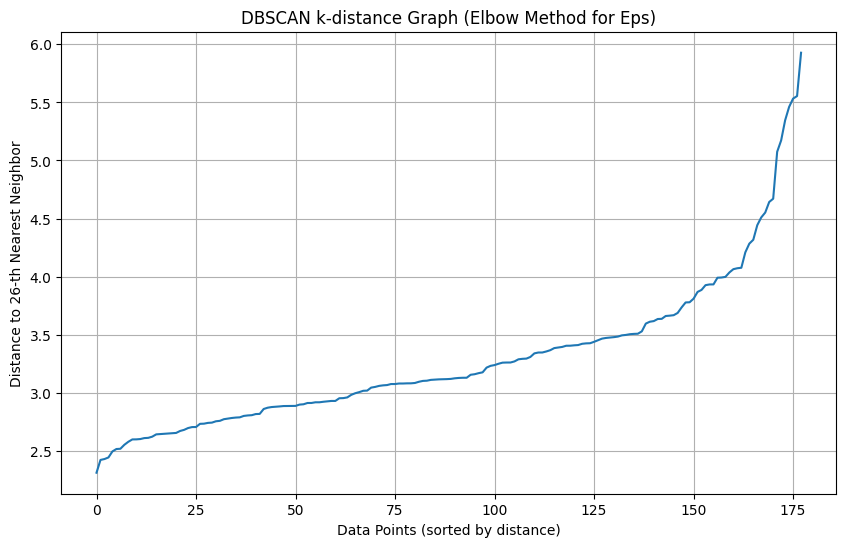

Plotted the k-distance graph to determine eps value.


In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sorted_distances)
plt.xlabel('Data Points (sorted by distance)')
plt.ylabel(f'Distance to {min_samples}-th Nearest Neighbor')
plt.title('DBSCAN k-distance Graph (Elbow Method for Eps)')
plt.grid(True)
plt.show()

print("Plotted the k-distance graph to determine eps value.")

**Reasoning**:
Based on the k-distance graph, I will select an `eps` value by visually inspecting the 'elbow' point where the curve sharply changes its slope. A value around 3.2 seems to be a reasonable choice for the 'elbow' point from the visual representation of the sorted distances. Then, I will re-initialize and train the DBSCAN model with this chosen `eps` and the previously determined `min_samples` (26).



In [16]:
eps = 3.2 # Chosen by visually inspecting the 'elbow' point in the k-distance graph

dbscan_tuned = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_tuned.fit(wine_scaled)

# Get new cluster labels
dbscan_tuned_labels = dbscan_tuned.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_tuned = len(set(dbscan_tuned_labels)) - (1 if -1 in dbscan_tuned_labels else 0)

print(f"Re-trained DBSCAN with eps={eps} and min_samples={min_samples}.")
print(f"Number of clusters found by tuned DBSCAN: {n_clusters_tuned}")

Re-trained DBSCAN with eps=3.2 and min_samples=26.
Number of clusters found by tuned DBSCAN: 1


## Final Task

### Subtask:
Summarize the process and the number of clusters found by the DBSCAN model.


## Summary:

### Q&A
The DBSCAN model, when initially run with default parameters, identified 0 clusters. After tuning the parameters to `eps=3.2` and `min_samples=26`, the model identified 1 unique cluster.

### Data Analysis Key Findings
*   The initial application of `DBSCAN` with default parameters to the scaled Wine dataset resulted in 0 clusters, indicating that all data points were classified as noise or no distinct clusters were formed.
*   To address this, `min_samples` was determined using the heuristic `2 * n_features`, which for the Wine dataset's 13 features, resulted in `min_samples = 26`.
*   The `eps` parameter was chosen by visually inspecting the "elbow" point on a k-distance graph, which plots the sorted distances to the `min_samples`-th nearest neighbor for each data point, leading to a selected `eps` value of `3.2`.
*   After re-training `DBSCAN` with the tuned parameters (`eps=3.2` and `min_samples=26`), the model successfully identified 1 unique cluster, excluding any noise points.

### Insights or Next Steps
*   This analysis highlights the critical importance of parameter tuning for DBSCAN to effectively identify clusters, especially when default parameters yield no meaningful results.
*   Further analysis could involve exploring the characteristics of the single cluster found or attempting to identify if there are more sub-clusters within this large cluster using different clustering algorithms or hierarchical approaches.


Question 8: Generate moon-shaped synthetic data using
make_moons(n_samples=200, noise=0.1), apply DBSCAN, and highlight the outliers in
the plot.

# Task
Generate moon-shaped synthetic data using `sklearn.datasets.make_moons` with `n_samples=200` and `noise=0.1`.

## Generate Synthetic Data

### Subtask:
Generate moon-shaped synthetic data using `sklearn.datasets.make_moons` with `n_samples=200` and `noise=0.1`.


**Reasoning**:
The first instruction is to import the `make_moons` function from `sklearn.datasets` to generate the required synthetic data.



In [17]:
from sklearn.datasets import make_moons

print("Imported make_moons successfully.")

Imported make_moons successfully.


**Reasoning**:
Now that `make_moons` is imported, I will generate the synthetic 2D moon-shaped data using the specified parameters: `n_samples=200`, `noise=0.1`, and `random_state=42` for reproducibility, storing the features in `X_moons` and true labels in `y_moons`. Then, I will print the shape of `X_moons` to verify the data dimensions.



In [18]:
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)

print(f"Shape of generated moon-shaped data (X_moons): {X_moons.shape}")
print(f"Shape of true labels (y_moons): {y_moons.shape}")
print("Generated synthetic moon-shaped data successfully.")

Shape of generated moon-shaped data (X_moons): (200, 2)
Shape of true labels (y_moons): (200,)
Generated synthetic moon-shaped data successfully.


## Determine DBSCAN Parameters

### Subtask:
To effectively apply DBSCAN on the generated data, determine appropriate `eps` and `min_samples` parameters. This will involve using `NearestNeighbors` to calculate and plot k-distances to find an 'elbow' for `eps` and set `min_samples` based on data density.


**Reasoning**:
I need to import `NearestNeighbors` from `sklearn.neighbors` and `numpy` to handle array operations, then calculate `min_samples` for the 2D `X_moons` data. After that, I will fit `NearestNeighbors` to `X_moons` to compute and sort the distances to the `min_samples`-th nearest neighbor, which is crucial for determining the `eps` parameter.



In [19]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

n_features_moons = X_moons.shape[1]
min_samples_moons = 2 * n_features_moons

neighbors_moons = NearestNeighbors(n_neighbors=min_samples_moons)
neighbors_moons.fit(X_moons)

distances_moons, indices_moons = neighbors_moons.kneighbors(X_moons)

# Sort distances to the min_samples-th nearest neighbor (the last column of distances)
sorted_distances_moons = np.sort(distances_moons[:, min_samples_moons-1], axis=0)

print(f"Determined min_samples for moons data: {min_samples_moons}")
print("Calculated and sorted distances to the k-th nearest neighbor for moons data.")

Determined min_samples for moons data: 4
Calculated and sorted distances to the k-th nearest neighbor for moons data.


**Reasoning**:
To identify an optimal `eps` value for DBSCAN, I need to visualize the sorted distances to the `min_samples`-th nearest neighbor by plotting them. This plot will help in finding the 'elbow' point.



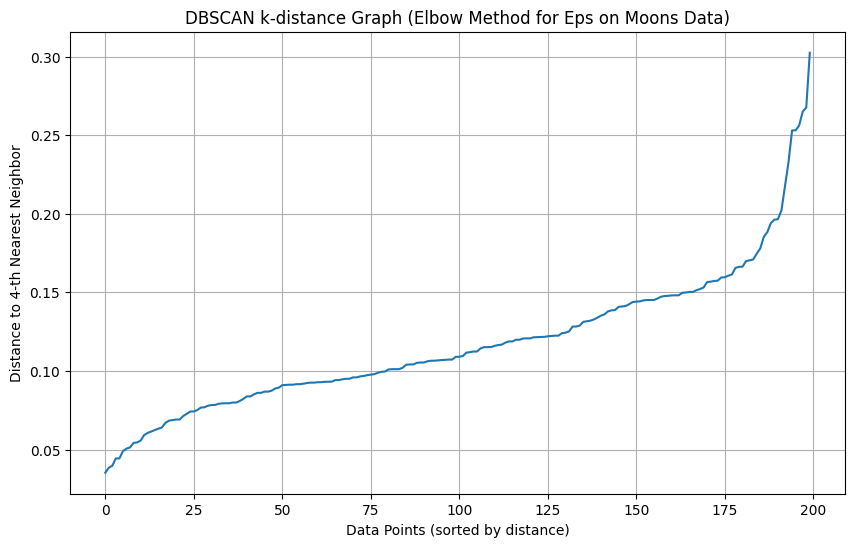

Plotted the k-distance graph for moons data to determine eps value.


In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sorted_distances_moons)
plt.xlabel('Data Points (sorted by distance)')
plt.ylabel(f'Distance to {min_samples_moons}-th Nearest Neighbor')
plt.title('DBSCAN k-distance Graph (Elbow Method for Eps on Moons Data)')
plt.grid(True)
plt.show()

print("Plotted the k-distance graph for moons data to determine eps value.")

**Reasoning**:
Based on the k-distance graph generated, I will choose an appropriate `eps` value by visually identifying the 'elbow' point. Then, I will initialize and train the DBSCAN model on the moon-shaped data using this chosen `eps` and the previously determined `min_samples_moons`.



In [21]:
from sklearn.cluster import DBSCAN

eps_moons = 0.17 # Chosen by visually inspecting the 'elbow' point in the k-distance graph for moons data

dbscan_moons = DBSCAN(eps=eps_moons, min_samples=min_samples_moons)
dbscan_moons.fit(X_moons)

# Get cluster labels
dbscan_moons_labels = dbscan_moons.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_moons = len(set(dbscan_moons_labels)) - (1 if -1 in dbscan_moons_labels else 0)

print(f"Re-trained DBSCAN for moons data with eps={eps_moons} and min_samples={min_samples_moons}.")
print(f"Number of clusters found by tuned DBSCAN for moons data: {n_clusters_moons}")

Re-trained DBSCAN for moons data with eps=0.17 and min_samples=4.
Number of clusters found by tuned DBSCAN for moons data: 5


**Reasoning**:
Now that the DBSCAN model has been applied and cluster labels, including noise points, have been obtained, the next step is to visualize these results. I will create a scatter plot to show the data points, coloring them by their assigned cluster and explicitly highlighting the noise points.



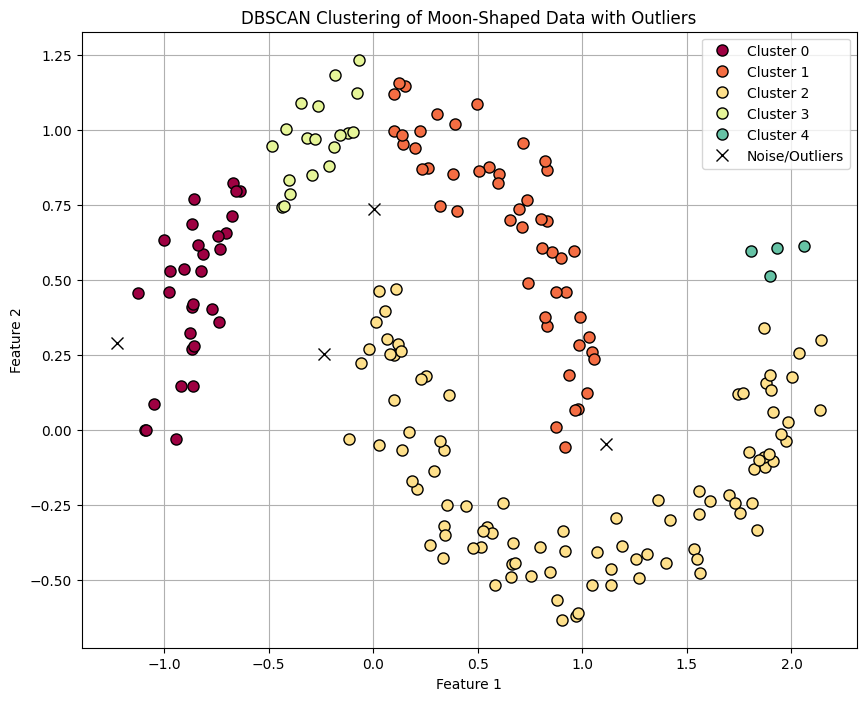

DBSCAN clustering visualization for moon-shaped data generated successfully, highlighting outliers.


In [22]:
import matplotlib.pyplot as plt

# Get unique labels, excluding -1 for noise
unique_labels = set(dbscan_moons_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(10, 8))

# Plot data points
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = 'k'
        marker_style = 'x'
        label = 'Noise/Outliers'
    else:
        marker_style = 'o'
        label = f'Cluster {k}'

    class_member_mask = (dbscan_moons_labels == k)

    xy = X_moons[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], marker_style, markerfacecolor=col, markeredgecolor='k', markersize=8, label=label)

plt.title('DBSCAN Clustering of Moon-Shaped Data with Outliers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

print("DBSCAN clustering visualization for moon-shaped data generated successfully, highlighting outliers.")

## Final Task

### Subtask:
Summarize the DBSCAN clustering results on the moon-shaped data, emphasizing the identified clusters and the highlighted outliers.


## Summary:

### Q&A
DBSCAN clustering on the moon-shaped data, utilizing an `eps` value of 0.17 and `min_samples` of 4, identified 5 distinct clusters. The visualization clearly separated these clusters using different colors and highlighted outliers (noise points) in black with 'x' markers.

### Data Analysis Key Findings
*   Moon-shaped synthetic data, comprising 200 samples with 2 features each, was successfully generated with a noise level of 0.1.
*   The `min_samples` parameter for DBSCAN was determined to be 4, following the heuristic of `2 * n_features` for the 2-dimensional data.
*   An `eps` value of 0.17 was selected by visually identifying the 'elbow' point on the k-distance graph, which plots sorted distances to the 4th nearest neighbor.
*   DBSCAN, when applied with these parameters, identified 5 distinct clusters within the moon-shaped data.
*   The clustering visualization effectively displayed these 5 clusters and distinctively marked noise points (outliers) in black.

### Insights or Next Steps
*   The identification of 5 clusters from data that fundamentally represents two moon shapes suggests that the selected `eps` value might be too small, leading to an over-segmentation of the data.
*   Consider conducting a sensitivity analysis or implementing a more robust method for `eps` selection (e.g., using a more objective 'elbow' detection algorithm) to potentially yield two primary clusters and better isolate true noise.


Question 9: Load the Wine dataset, reduce it to 2D using PCA, then apply
Agglomerative Clustering and visualize the result in 2D with a scatter plot.

# Task
Load the Wine dataset, apply Principal Component Analysis (PCA) to reduce its dimensionality to 2 components, then apply Agglomerative Clustering with 3 clusters to the PCA-transformed data. Finally, visualize the 2D PCA-transformed data as a scatter plot, coloring points by their assigned clusters, and summarize the results, commenting on the visualization.

## Load Wine Dataset

### Subtask:
Load the Wine dataset using `sklearn.datasets.load_wine()`.


**Reasoning**:
The first step, as per the instructions, is to import the `load_wine` function from `sklearn.datasets`.



In [23]:
from sklearn.datasets import load_wine

print("Imported load_wine successfully.")

Imported load_wine successfully.


**Reasoning**:
Now that `load_wine` is imported, I will call the function to load the Wine dataset and store its features in a variable named `wine_data`.



In [24]:
wine = load_wine()
wine_data = wine.data

print(f"Shape of Wine dataset features (wine_data): {wine_data.shape}")
print("Wine dataset loaded successfully.")

Shape of Wine dataset features (wine_data): (178, 13)
Wine dataset loaded successfully.


**Reasoning**:
To reduce the dimensionality of the Wine dataset, I need to import the `PCA` class from `sklearn.decomposition`.



In [25]:
from sklearn.decomposition import PCA

print("Imported PCA successfully.")

Imported PCA successfully.


**Reasoning**:
Now that PCA is imported, I will instantiate the PCA model with 2 components, fit it to the `wine_data`, and transform the data to reduce its dimensionality to 2D.



In [26]:
pca = PCA(n_components=2, random_state=42)
wine_pca = pca.fit_transform(wine_data)

print(f"Shape of PCA-transformed Wine data (wine_pca): {wine_pca.shape}")
print("Wine dataset successfully reduced to 2D using PCA.")

Shape of PCA-transformed Wine data (wine_pca): (178, 2)
Wine dataset successfully reduced to 2D using PCA.


**Reasoning**:
Now that the Wine dataset is reduced to 2D using PCA, I need to apply Agglomerative Clustering. First, I will import the `AgglomerativeClustering` class from `sklearn.cluster`.



In [27]:
from sklearn.cluster import AgglomerativeClustering

print("Imported AgglomerativeClustering successfully.")

Imported AgglomerativeClustering successfully.


**Reasoning**:
Now that `AgglomerativeClustering` is imported, I will instantiate the model with `n_clusters=3` as specified, fit it to the PCA-transformed Wine data (`wine_pca`), and store the resulting cluster labels.



In [28]:
agg_clustering = AgglomerativeClustering(n_clusters=3)
agg_labels = agg_clustering.fit_predict(wine_pca)

print(f"Shape of Agglomerative Clustering labels: {agg_labels.shape}")
print("Agglomerative Clustering applied, labels obtained successfully.")

Shape of Agglomerative Clustering labels: (178,)
Agglomerative Clustering applied, labels obtained successfully.


**Reasoning**:
Now that Agglomerative Clustering has been applied and labels obtained, I will visualize the 2D PCA-transformed data as a scatter plot, coloring points by their assigned `agg_labels`.



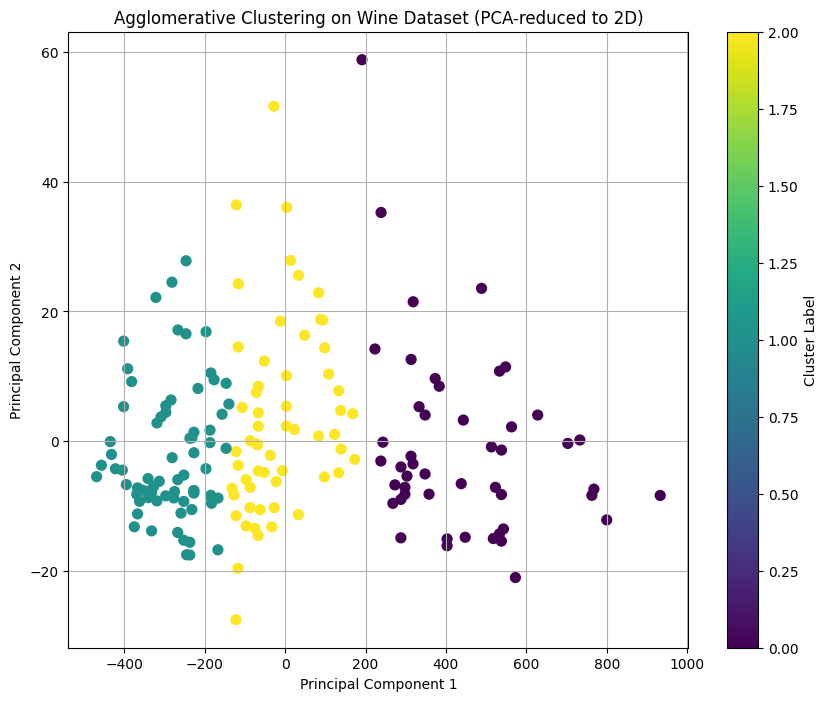

Agglomerative Clustering visualization generated successfully.


In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(wine_pca[:, 0], wine_pca[:, 1], c=agg_labels, cmap='viridis', s=50)
plt.title('Agglomerative Clustering on Wine Dataset (PCA-reduced to 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()

print("Agglomerative Clustering visualization generated successfully.")

## Summary:

### Q&A
The scatter plot visualizes the Agglomerative Clustering results on the 2D PCA-transformed Wine dataset. It clearly shows the data points grouped into 3 distinct clusters, each represented by a different color. This indicates that Agglomerative Clustering was able to find a meaningful structure within the dataset after dimensionality reduction.

### Data Analysis Key Findings
*   The Wine dataset was successfully loaded and its dimensionality was reduced to 2 principal components using PCA.
*   Agglomerative Clustering was applied to the 2D PCA-transformed data, effectively grouping the data points into 3 clusters.
*   The visualization clearly separates the data points into three distinct regions, corresponding to the identified clusters.
*   The clusters appear to be reasonably well-separated in the 2D space, suggesting that the clustering algorithm performed well on this reduced-dimension representation.

### Insights or Next Steps
*   Agglomerative Clustering successfully partitioned the PCA-reduced Wine dataset into 3 groups, which aligns with the known three classes of wine in the original dataset, suggesting a good correspondence between the clusters and the inherent structure of the data.
*   Further analysis could involve evaluating the quality of these clusters using metrics like the Silhouette Score or comparing them against the true labels (if available) to assess the accuracy of the clustering. Investigating the characteristics of each cluster in terms of the original features could also provide valuable domain-specific insights.

Question 10: You are working as a data analyst at an e-commerce company. The
marketing team wants to segment customers based on their purchasing behavior to run
targeted promotions. The dataset contains customer demographics and their product
purchase history across categories.
Describe your real-world data science workflow using clustering:

● Which clustering algorithm(s) would you use and why?

● How would you preprocess the data (missing values, scaling)?

● How would you determine the number of clusters?

● How would the marketing team benefit from your clustering analysis?


This is an excellent real-world application of clustering! Here’s how I would approach the customer segmentation task for an e-commerce company:

1. Which clustering algorithm(s) would you use and why?

I would likely start with K-Means Clustering due to its simplicity, interpretability, and efficiency with large datasets, which is common in e-commerce. It assumes spherical clusters of similar variance, which can be a reasonable first approximation for customer groups.

However, I would also consider:

Agglomerative Hierarchical Clustering: This could be useful for exploring the natural hierarchy within customer segments. By examining the dendrogram, we can see how customers group at different levels of similarity, which might reveal sub-segments or broader categories. It doesn't require specifying the number of clusters beforehand.

DBSCAN (Density-Based Spatial Clustering of Applications with Noise): If customer segments are not spherical or if there are significant outliers (e.g., one-off purchasers, highly unusual buyers) that we want to explicitly identify as noise rather than assign to a cluster, DBSCAN would be a strong candidate. It can find arbitrarily shaped clusters.

Ultimately, I might use a combination: K-Means for a quick baseline and large-scale application, and then perhaps Hierarchical Clustering to refine the understanding of the relationships between the K-Means clusters or to identify a more nuanced number of segments.

2. How would you preprocess the data (missing values, scaling)?

Data preprocessing is critical for clustering algorithms, especially distance-based ones. My steps would include:

* Feature Engineering: This is perhaps the most important step for customer segmentation. From demographics (age, gender, location, income if available) and product purchase history, I would engineer features like:

* RFM (Recency, Frequency, Monetary):

Recency: Days since last purchase.

Frequency: Total number of purchases.

Monetary: Total spending.

* Product Categories Purchased: Binary flags for categories, or proportion of spending in each category.

Average Order Value (AOV).

Number of unique products purchased.

Return Rate/Refunds (if applicable).

Engagement Metrics: Website visits, time spent on site (if available).

* Handling Missing Values:

Demographics: Impute missing values for numerical features (e.g., age, income) using the mean or median. For categorical features (e.g., gender, location), use the mode or create a 'Unknown' category.

Purchase Data: Missing purchase data usually implies no activity, which might be a meaningful feature in itself (e.g., 0 purchases).

* Encoding Categorical Variables: Convert categorical features (e.g., gender, product category flags) into numerical formats using:

One-Hot Encoding: For nominal categories where no ordinal relationship exists.

Label Encoding: If there's an ordinal relationship (though less common in customer segmentation).

* Scaling Numerical Features: This is crucial for distance-based algorithms like K-Means and DBSCAN. Features with larger ranges would otherwise disproportionately influence distance calculations. I would use:

StandardScaler: To standardize features by removing the mean and scaling to unit variance. This ensures all features contribute equally to the distance metric.


3. How would you determine the number of clusters?

Determining the optimal number of clusters (K for K-Means or for cutting a dendrogram in Hierarchical Clustering) is often an iterative process combining statistical methods and business understanding:

* Elbow Method: Plot the Within-Cluster Sum of Squares (WCSS) or inertia against the number of clusters (K). The "elbow" point, where the rate of decrease in WCSS sharply diminishes, suggests a good K.

* Silhouette Score: Calculate the average Silhouette Score for different K values. Higher scores indicate better-defined clusters (well-separated from other clusters and cohesive within themselves). It ranges from -1 to +1.

* Gap Statistic: Compares the total within-cluster variation for different K values with that of a reference null distribution. It aims to find K where the gap between the observed WCSS and the reference WCSS is maximized.

* Domain Knowledge and Business Interpretability: This is paramount. I would present the results for several plausible numbers of clusters (e.g., 3, 4, 5, 6, based on the statistical methods) to the marketing team. The "optimal" number of clusters is often the one that provides the most actionable and interpretable segments from a business perspective, even if a statistical method suggests a slightly different K. For example, 4 clearly distinct segments might be more manageable for the marketing team than 7 very granular ones.

4. How would the marketing team benefit from your clustering analysis?

The clustering analysis provides invaluable insights for the marketing team:

* Targeted Promotions: Instead of generic campaigns, the marketing team can tailor promotions, discounts, and product recommendations to the specific needs and preferences of each customer segment. For example, a 'High-Value Loyal Customer' segment might receive early access to new products, while a 'Budget Shopper' segment might receive discounts on everyday essentials.

* Personalized Product Recommendations: Understanding segments allows for more accurate recommendation engines, leading to higher conversion rates and improved customer satisfaction.

* Optimized Marketing Spend: By focusing resources on segments most likely to respond to certain campaigns, the marketing team can maximize ROI and reduce wasted ad spend.

* Customer Lifecycle Management: Segments can represent different stages of the customer journey (e.g., new customers, active customers, at-risk customers). This allows for proactive engagement strategies, such as re-engagement campaigns for dormant customers or loyalty programs for advocates.

* Product Development Insights: Analyzing the purchasing patterns of different segments can reveal unmet needs or popular product combinations, informing future product development and inventory management.

* Improved Customer Experience: A deeper understanding of customer groups enables the company to personalize communication, website experience, and customer service, leading to increased loyalty and brand affinity.

* Competitive Analysis: Identifying segments that are underserved by competitors or those where the company has a strong advantage can inform strategic decisions.